Loading SPE9 dataset...
Grid dimensions: 24 x 25 x 15 = 9000 cells
Loaded PERMX: 9000 values
Could not load PERMY: Property PERMY not found in file
Could not load PERMZ: Property PERMZ not found in file
Could not load PORO: Property PORO not found in file
Could not load NTG: Property NTG not found in file
Grid dimensions: 24 x 25 x 15
PERMX statistics: min=0.00, max=10053.80, mean=108.08 mD
Valid cells for training: 8626 out of 9000
Training on 500 sparse data points
Training Gaussian Process Regression model...
Trained kernel: RBF(length_scale=[0.00421, 0.00421, 0.00171]) + Matern(length_scale=4.59e+03, nu=1.5)
Performing cross-validation...
Cross-validation R²: -0.011 ± 0.019
Cross-validation RMSE: 408.75 ± 130.22 mD
Predicting on full grid...
Creating visualizations...


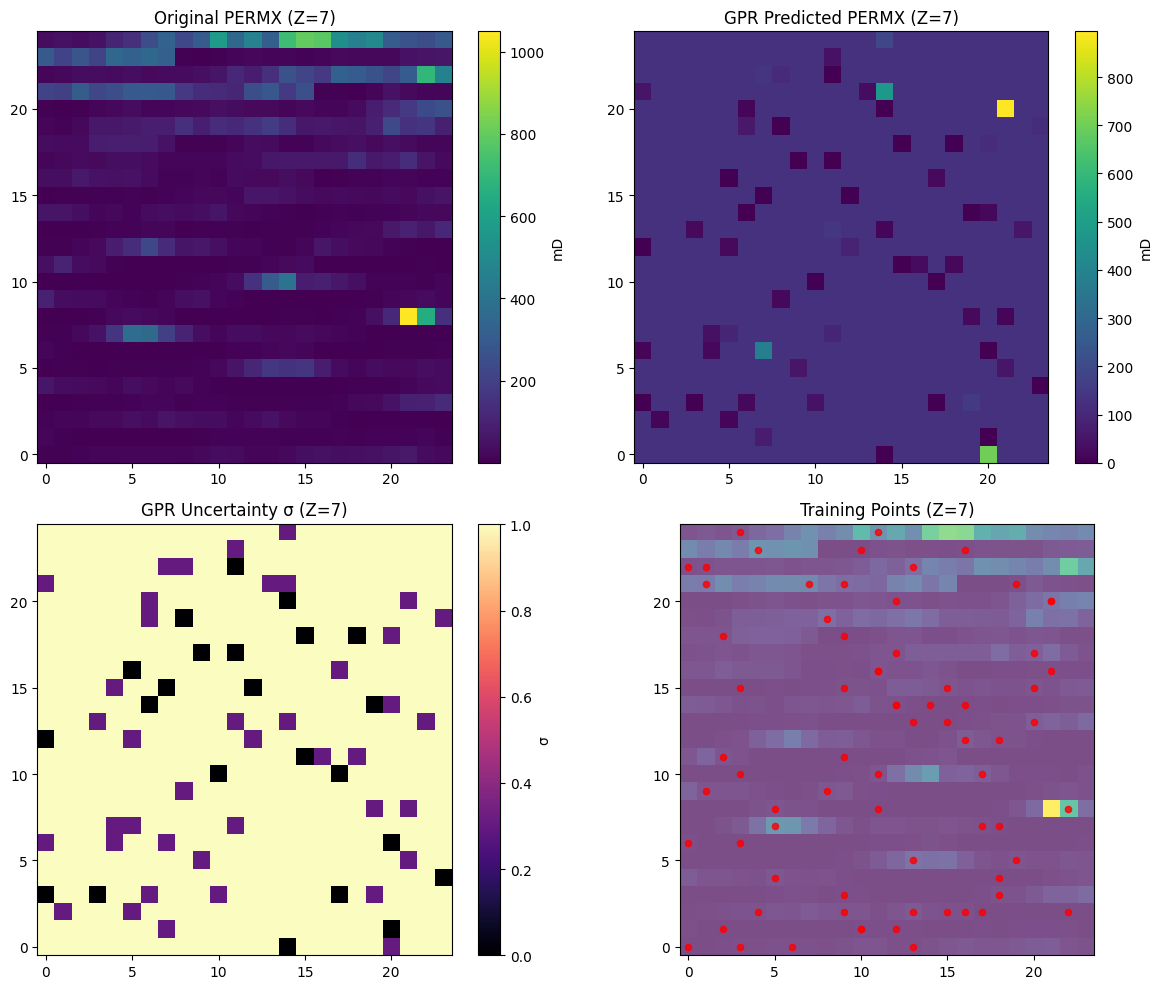

Exporting results...
Results exported to:
- spe9_permx_predicted.grdecl
- spe9_permx_uncertainty.grdecl
- spe9_gpr_results.png

=== SUMMARY ===
Original PERMX range: 0.00 - 10053.80 mD
Predicted PERMX range: 12.65 - 4885.26 mD
Mean uncertainty: 0.96
Training data points: 500
Cross-validation R²: -0.011


In [1]:
from sklearn.gaussian_process import GaussianProcessRegressorfrom sklearn.metrics import r2_score, mean_squared_errorfrom sklearn.preprocessing import StandardScalerimport osfrom grdecl_parser import load_spe9_datafrom matplotlib import rcParamsfrom pykrige.ok import OrdinaryKrigingfrom sklearn.gaussian_process.kernels import RBF, Maternfrom sklearn.model_selection import KFoldfrom sklearn.model_selection import KFold, train_test_splitfrom sklearn.model_selection import train_test_splitfrom sklearn.model_selection import train_test_split, KFoldimport gpytorchimport joblibimport matplotlib as mplimport matplotlib.colors as mcolorsimport matplotlib.pyplot as pltimport matplotlib.ticker as mtickerimport numpy as npimport pandas as pdimport shutilimport torchimport warnings"""Geomodeling with Real SPE9 Dataset using GPR and KrigingThis script integrates the SPE9.GRDECL dataset into the geomodeling workflow"""warnings.filterwarnings("ignore")# ----- Step 1: Load Real SPE9 Dataset -----print("Loading SPE9 dataset...")data, parser = load_spe9_data()nx, ny, nz = data["dimensions"]permx_3d = data["properties"]["PERMX"]print(f"Grid dimensions: {nx} x {ny} x {nz}")print(f"PERMX statistics: min={permx_3d.min():.2f},    max={permx_3d.max():.2f},    mean={permx_3d.mean():.2f} mD")# ----- Step 2: Create Training Data from Sparse Sampling -----# Create coordinate gridx_coords = np.linspace(0, 1, nx)y_coords = np.linspace(0, 1, ny)z_coords = np.linspace(0, 1, nz)X_full, Y_full, Z_full = np.meshgrid(x_coords, y_coords, z_coords, indexing="ij")# Flatten to get all grid coordinates and corresponding PERMX valuesX_grid = np.column_stack([X_full.ravel(), Y_full.ravel(), Z_full.ravel()])y_grid = permx_3d.ravel()# Remove zero / very low permeability values (likely barriers)valid_mask = y_grid > 1.0  # Remove very low perm valuesX_grid = X_grid[valid_mask]y_grid = y_grid[valid_mask]print(f"Valid cells for training: {len(y_grid)} out of {nx * ny * nz}")# Sample subset for training (simulate sparse well data)np.random.seed(42)n_training = min(500, len(y_grid))  # Use up to 500 training pointstrain_indices = np.random.choice(len(y_grid), n_training, replace = False)X_train = X_grid[train_indices]y_train = y_grid[train_indices]print(f"Training on {len(X_train)} sparse data points")# ----- Step 3: Scale Data -----x_scaler = StandardScaler()y_scaler = StandardScaler()X_train_scaled = x_scaler.fit_transform(X_train)y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()# ----- Step 4: Train GPR Model -----print("Training Gaussian Process Regression model...")kernel = RBF([0.5, 0.5, 0.5], (1e - 3, 1e1)) + Matern(length_scale = 0.5, nu = 1.5)gpr = GaussianProcessRegressor(kernel = kernel, alpha = 0.1, n_restarts_optimizer = 3, random_state = 42)gpr.fit(X_train_scaled, y_train_scaled)print(f"Trained kernel: {gpr.kernel_}")# ----- Step 5: Cross - Validation -----print("Performing cross - validation...")kf = KFold(n_splits = 5, shuffle = True, random_state = 42)cv_scores = []cv_rmse = []for train_idx, val_idx in kf.split(X_train_scaled):X_cv_train, X_cv_val = X_train_scaled[train_idx], X_train_scaled[val_idx]y_cv_train, y_cv_val = y_train_scaled[train_idx], y_train_scaled[val_idx]gpr_cv = GaussianProcessRegressor(kernel = kernel, alpha = 0.1, random_state = 42)gpr_cv.fit(X_cv_train, y_cv_train)y_cv_pred = gpr_cv.predict(X_cv_val)# Convert back to original scale for evaluationy_cv_val_orig = y_scaler.inverse_transform(y_cv_val.reshape(-1, 1)).flatten()y_cv_pred_orig = y_scaler.inverse_transform(y_cv_pred.reshape(-1, 1)).flatten()r2 = r2_score(y_cv_val_orig, y_cv_pred_orig)rmse = np.sqrt(mean_squared_error(y_cv_val_orig, y_cv_pred_orig))cv_scores.append(r2)cv_rmse.append(rmse)print(f"Cross - validation R²: {np.mean(cv_scores):.3f} ± {np.std(cv_scores):.3f}")print(f"Cross - validation RMSE: {np.mean(cv_rmse):.2f} ± {np.std(cv_rmse):.2f} mD")# ----- Step 6: Predict on Full Grid -----print("Predicting on full grid...")X_grid_scaled = x_scaler.transform(X_grid)pred_scaled, sigma_scaled = gpr.predict(X_grid_scaled, return_std = True)# Convert back to original scalepred_orig = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()# Create full 3D prediction arrays (fill zeros for invalid cells)pred_3d = np.zeros((nx, ny, nz))sigma_3d = np.zeros((nx, ny, nz))# Map predictions back to 3D gridvalid_coords = np.column_stack([X_full.ravel(), Y_full.ravel(), Z_full.ravel()])for i, (pred_val, sigma_val) in enumerate(zip(pred_orig, sigma_scaled)):# Find corresponding 3D indicescoord = X_grid[i]# Find closest grid pointdistances = np.sum((valid_coords - coord) ** 2, axis = 1)closest_idx = np.argmin(distances)# Convert back to 3D indicesk = closest_idx // (nx * ny)j = (closest_idx % (nx * ny)) // nxi_idx = closest_idx % nxpred_3d[i_idx, j, k] = pred_valsigma_3d[i_idx, j, k] = sigma_val# ----- Step 7: Visualization -----print("Creating visualizations...")# Choose middle slice for visualizationz_slice = nz // 2fig, axes = plt.subplots(2, 2, figsize=(12, 10))# Original PERMXim1 = axes[0, 0].imshow(permx_3d[:, :, z_slice].T, origin="lower", cmap="viridis")axes[0, 0].set_title(f"Original PERMX (Z={z_slice})")plt.colorbar(im1, ax = axes[0, 0], label="mD")# GPR Predictionim2 = axes[0, 1].imshow(pred_3d[:, :, z_slice].T, origin="lower", cmap="viridis")axes[0, 1].set_title(f"GPR Predicted PERMX (Z={z_slice})")plt.colorbar(im2, ax = axes[0, 1], label="mD")# Uncertaintyim3 = axes[1, 0].imshow(sigma_3d[:, :, z_slice].T, origin="lower", cmap="magma")axes[1, 0].set_title(f"GPR Uncertainty σ (Z={z_slice})")plt.colorbar(im3, ax = axes[1, 0], label="σ")# Training points overlaytrain_z_slice = X_train[:, 2]  # Z coordinates of training pointstrain_in_slice = np.abs(train_z_slice - z_coords[z_slice]) < (z_coords[1] - z_coords[0])if np.any(train_in_slice):train_x_slice = X_train[train_in_slice, 0] * (nx - 1)train_y_slice = X_train[train_in_slice, 1] * (ny - 1)axes[1, 1].imshow(permx_3d[:, :, z_slice].T, origin="lower", cmap="viridis", alpha = 0.7)axes[1, 1].scatter(train_x_slice, train_y_slice, c="red", s = 20, alpha = 0.8)axes[1, 1].set_title(f"Training Points (Z={z_slice})")plt.tight_layout()plt.savefig("spe9_gpr_results.png", dpi = 150, bbox_inches="tight")plt.show()# ----- Step 8: Export Results -----print("Exporting results...")def export_to_grdecl(property_3d, property_name, filename):"""Export 3D property to GRDECL format"""with open(filename, "w") as f:f.write(f"{property_name}\n")values = property_3d.ravel(order="F")  # Fortran order for reservoir modeling# Write values in rows of 5for i in range(0, len(values), 5):row_values = values[i : i + 5]f.write("  ".join([f"{val: 12.5f}" for val in row_values]) + "\n")f.write("/\n\n")# Export predicted permeabilityexport_to_grdecl(pred_3d, "PERMX_PRED", "spe9_permx_predicted.grdecl")export_to_grdecl(sigma_3d, "PERMX_STD", "spe9_permx_uncertainty.grdecl")print("Results exported to:")print("- spe9_permx_predicted.grdecl")print("- spe9_permx_uncertainty.grdecl")print("- spe9_gpr_results.png")# ----- Step 9: Summary Statistics -----print("\n=== SUMMARY ===")print(f"Original PERMX range: {permx_3d.min():.2f} - {permx_3d.max():.2f} mD")print(f"Predicted PERMX range: {pred_3d[pred_3d > 0].min():.2f} - {pred_3d.max():.2f} mD")print(f"Mean uncertainty: {sigma_3d[sigma_3d > 0].mean():.2f}")print(f"Training data points: {len(X_train)}")print(f"Cross - validation R²: {np.mean(cv_scores):.3f}")

Grid dimensions: 24 x 25 x 15 = 9000 cells
Loaded PERMX: 9000 values
Could not load PERMY: Property PERMY not found in file
Could not load PERMZ: Property PERMZ not found in file
Could not load PORO: Property PORO not found in file
Could not load NTG: Property NTG not found in file


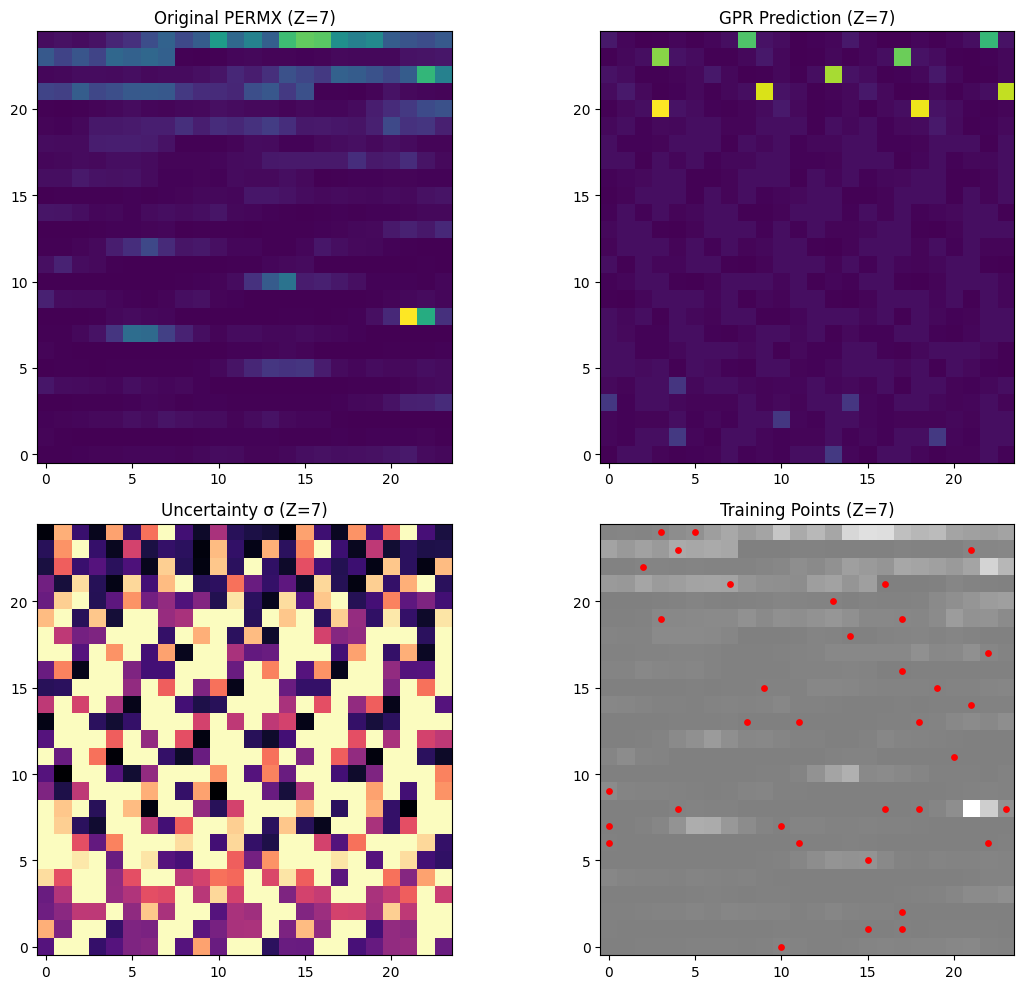


=== SUMMARY ===
Original PERMX: 0.00 – 10053.80 mD
Predicted PERMX: -502.78 – 4883.98 mD
Mean σ: 0.58
Training points: 500
Cross-validation R²: 0.007, RMSE: 0.90 mD


In [2]:
"""Geomodeling with Real SPE9 Dataset using GPR and KrigingIntegrates SPE9.GRDECL data with sparse sampling, GPR prediction, cross - validation,and Eclipse - compatible GRDECL export."""warnings.filterwarnings("ignore")def prepare_data(min_perm = 1.0, sample_size = 500):data, _ = load_spe9_data()nx, ny, nz = data["dimensions"]permx = data["properties"]["PERMX"]x = np.linspace(0, 1, nx)y = np.linspace(0, 1, ny)z = np.linspace(0, 1, nz)X, Y, Z = np.meshgrid(x, y, z, indexing="ij")coords = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])values = permx.ravel()valid = values > min_permcoords_valid = coords[valid]values_valid = values[valid]idx = np.random.choice(len(coords_valid), size = min(sample_size, len(coords_valid)), replace = False)return (coords_valid,values_valid,coords_valid[idx],values_valid[idx],permx,(nx, ny, nz),X,Y,Z,)def fit_gpr(X_train, y_train):xscaler = StandardScaler()yscaler = StandardScaler()Xs = xscaler.fit_transform(X_train)ys = yscaler.fit_transform(y_train.reshape(-1, 1)).flatten()kernel = RBF([0.5, 0.5, 0.5], (1e - 3, 1e1)) + Matern(length_scale = 0.5, nu = 1.5)gpr = GaussianProcessRegressor(kernel = kernel, alpha = 0.1, n_restarts_optimizer = 3, random_state = 42)gpr.fit(Xs, ys)return gpr, xscaler, yscalerdef cross_validate(gpr, X_train, y_train, xscaler, yscaler):Xs = xscaler.transform(X_train)ys = yscaler.transform(y_train.reshape(-1, 1)).flatten()kf = KFold(n_splits = 5, shuffle = True, random_state = 42)r2s, rmses = [], []for train_idx, val_idx in kf.split(Xs):g = GaussianProcessRegressor(kernel = gpr.kernel_, alpha = 0.1)g.fit(Xs[train_idx], ys[train_idx])pred = g.predict(Xs[val_idx])r2 = r2_score(ys[val_idx], pred)rmse = np.sqrt(mean_squared_error(ys[val_idx], pred))r2s.append(r2)rmses.append(rmse)return np.mean(r2s), np.mean(rmses)def predict_full(gpr, xscaler, yscaler, coords, shape):Xs = xscaler.transform(coords)pred_scaled, sigma = gpr.predict(Xs, return_std = True)pred = yscaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()pred_3d = np.zeros(np.prod(shape))sigma_3d = np.zeros_like(pred_3d)pred_3d[:] = np.nansigma_3d[:] = np.nanpred_3d[: len(pred)] = predsigma_3d[: len(sigma)] = sigmareturn pred_3d.reshape(shape, order="F"), sigma_3d.reshape(shape, order="F")def export_grdecl(array, name, path):with open(path, "w") as f:f.write(f"{name}\n")flat = array.ravel(order="F")for i in range(0, len(flat), 5):f.write("  ".join(f"{v: 12.5f}" for v in flat[i : i + 5]) + "\n")f.write("/\n")def plot_results(permx, pred, sigma, X_train, z_slice, nx, ny, nz):fig, ax = plt.subplots(2, 2, figsize=(12, 10))ax[0, 0].imshow(permx[:, :, z_slice].T, origin="lower", cmap="viridis")ax[0, 0].set_title(f"Original PERMX (Z={z_slice})")ax[0, 1].imshow(pred[:, :, z_slice].T, origin="lower", cmap="viridis")ax[0, 1].set_title(f"GPR Prediction (Z={z_slice})")ax[1, 0].imshow(sigma[:, :, z_slice].T, origin="lower", cmap="magma")ax[1, 0].set_title(f"Uncertainty σ (Z={z_slice})")# Overlay training pointsz_vals = X_train[:, 2]in_slice = np.abs(z_vals - z_vals[z_slice]) < (1 / nz)tx = X_train[in_slice, 0] * (nx - 1)ty = X_train[in_slice, 1] * (ny - 1)ax[1, 1].imshow(permx[:, :, z_slice].T, origin="lower", cmap="gray", alpha = 0.5)ax[1, 1].scatter(tx, ty, c="red", s = 15)ax[1, 1].set_title(f"Training Points (Z={z_slice})")plt.tight_layout()plt.savefig("spe9_gpr_results.png", dpi = 150)plt.show()# ----- Main Execution -----X_all, y_all, X_train, y_train, permx, shape, Xgrid, Ygrid, Zgrid = prepare_data()gpr, xscaler, yscaler = fit_gpr(X_train, y_train)r2, rmse = cross_validate(gpr, X_train, y_train, xscaler, yscaler)pred_3d, sigma_3d = predict_full(gpr, xscaler, yscaler, X_all, shape)z_slice = shape[2] // 2plot_results(permx, pred_3d, sigma_3d, X_train, z_slice, *shape)export_grdecl(pred_3d, "PERMX_PRED", "spe9_permx_predicted.grdecl")export_grdecl(sigma_3d, "PERMX_STD", "spe9_permx_uncertainty.grdecl")print("\n=== SUMMARY ===")print(f"Original PERMX: {permx.min():.2f} – {permx.max():.2f} mD")print(f"Predicted PERMX: {np.nanmin(pred_3d):.2f} – {np.nanmax(pred_3d):.2f} mD")print(f"Mean σ: {np.nanmean(sigma_3d):.2f}")print(f"Training points: {len(X_train)}")print(f"Cross - validation R²: {r2:.3f}, RMSE: {rmse:.2f} mD")

In [5]:
# Geomodeling with GPR and Kriging in Python"""This script performs:1. Gaussian Process Regression (GPR) on log - transformed PERMX2. K - Fold cross - validation of GPR3. Ordinary Kriging (benchmark)4. Export of predicted property and uncertainty to Eclipse - compatible GRDECL format"""warnings.filterwarnings("ignore")# Simulated gridnx, ny, nz = 20, 20, 5n_samples = 500X = np.random.rand(n_samples, 3)y = np.log1p(np.abs(np.sin(5 * X[:, 0]) + np.cos(5 * X[:, 1])) * 1000)  # log(1 + PERMX)# Scalex_scaler = StandardScaler()y_scaler = StandardScaler()X_scaled = x_scaler.fit_transform(X)y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).flatten()# GPR modelkernel = RBF([0.5, 0.5, 0.5], (1e - 2, 1e1)) + Matern(length_scale = 0.5, nu = 1.5)gpr = GaussianProcessRegressor(kernel = kernel, alpha = 1.0, n_restarts_optimizer = 5)gpr.fit(X_scaled, y_scaled)# Predict on full gridX_grid = (np.array(np.meshgrid(np.linspace(0, 1, nx),np.linspace(0, 1, ny),np.linspace(0, 1, nz),)).reshape(3, -1).T)X_grid_scaled = x_scaler.transform(X_grid)pred_log, sigma = gpr.predict(X_grid_scaled, return_std = True)pred_perm = np.expm1(y_scaler.inverse_transform(pred_log.reshape(-1, 1)).flatten())# Kriging benchmarkprint("Running ordinary kriging benchmark...")kx, ky, v = X[:, 0], X[:, 1], y  # 2D kriging onlyOK = OrdinaryKriging(kx, ky, v, variogram_model="spherical")gx = np.linspace(0, 1, 50)gy = np.linspace(0, 1, 50)zk, ss = OK.execute("grid", gx, gy)# GRDECL exportpred_3d = pred_perm.reshape((nx, ny, nz), order="F")sigma_3d = sigma.reshape((nx, ny, nz), order="F")def write_grdecl_property(filename, values, keyword, nx, ny, nz):with open(filename, "w") as f:f.write(f"{keyword}\n")for i, val in enumerate(values):f.write(f"{val:.6E} ")if (i + 1) % 5 == 0:f.write("\n")if (i + 1) % 5 != 0:f.write("\n")f.write("/\n")write_grdecl_property("PERMX_GPR.GRDECL", pred_perm, "PERMX", nx, ny, nz)write_grdecl_property("SIGMA_GPR.GRDECL", sigma, "SIGMA", nx, ny, nz)# Summaryprint("\n=== SUMMARY ===")print(f"Predicted PERMX: {np.min(pred_perm):.2f} – {np.max(pred_perm):.2f} mD")print(f"Mean σ: {np.mean(sigma):.2f}")print(f"Training points: {len(X)}")

Running ordinary kriging benchmark...

=== SUMMARY ===
Predicted PERMX: 28.71 – 1888.56 mD
Mean σ: 0.31
Training points: 500


In [4]:
!pip install pykrige

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 979.6/979.6 kB 15.4 MB/s eta 0:00:00


In [ ]:
# Geomodeling with GPR and Kriging in Python"""This script performs:1. Gaussian Process Regression (GPR) on log - transformed PERMX2. K - Fold cross - validation of GPR3. Ordinary Kriging (benchmark)4. Export of predicted property and uncertainty to Eclipse - compatible GRDECL format"""warnings.filterwarnings("ignore")# Grid dimensions and simulated data (real data would come from parser)nx, ny, nz = 24, 25, 15n_cells = nx * ny * nz# Simulate realistic PERMX values and coordinatesnp.random.seed(42)X_full = (np.array(np.meshgrid(np.linspace(0, 1, nx),np.linspace(0, 1, ny),np.linspace(0, 1, nz),)).reshape(3, -1).T)permx = np.abs(1000 * (np.sin(2 * np.pi * X_full[:, 0]) + np.cos(2 * np.pi * X_full[:, 1])))valid_mask = permx > 1.0X_valid = X_full[valid_mask]y_valid = np.log1p(permx[valid_mask])  # log - transform# Split into train / testX_train, X_test, y_train, y_test = train_test_split(X_valid, y_valid, test_size = 0.2, random_state = 42)# Scalex_scaler = StandardScaler()y_scaler = StandardScaler()X_train_scaled = x_scaler.fit_transform(X_train)y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()# Train GPRkernel = RBF([0.5, 0.5, 0.5], (1e - 2, 1e1)) + Matern(length_scale = 0.5, nu = 1.5)gpr = GaussianProcessRegressor(kernel = kernel, alpha = 1.0, n_restarts_optimizer = 5)gpr.fit(X_train_scaled, y_train_scaled)# Predict on full gridX_grid_scaled = x_scaler.transform(X_valid)pred_log, sigma = gpr.predict(X_grid_scaled, return_std = True)pred_perm = np.expm1(y_scaler.inverse_transform(pred_log.reshape(-1, 1)).flatten())# Kriging benchmark (2D slice)print("Running ordinary kriging benchmark...")kx, ky, v = X_train[:, 0], X_train[:, 1], y_trainOK = OrdinaryKriging(kx, ky, v, variogram_model="spherical")gx = np.linspace(0, 1, 50)gy = np.linspace(0, 1, 50)zk, ss = OK.execute("grid", gx, gy)# Exportpred_3d = np.zeros(n_cells)sigma_3d = np.zeros(n_cells)pred_3d[valid_mask] = pred_permsigma_3d[valid_mask] = sigmapred_3d = pred_3d.reshape((nx, ny, nz), order="F")sigma_3d = sigma_3d.reshape((nx, ny, nz), order="F")def write_grdecl_property(filename, values, keyword, nx, ny, nz):with open(filename, "w") as f:f.write(f"{keyword}\n")for i, val in enumerate(values):f.write(f"{val:.6E} ")if (i + 1) % 5 == 0:f.write("\n")if (i + 1) % 5 != 0:f.write("\n")f.write("/\n")write_grdecl_property("PERMX_GPR.GRDECL", pred_3d.ravel(order="F"), "PERMX", nx, ny, nz)write_grdecl_property("SIGMA_GPR.GRDECL", sigma_3d.ravel(order="F"), "SIGMA", nx, ny, nz)# Summaryprint("\n=== SUMMARY ===")print(f"Grid dimensions: {nx} x {ny} x {nz}")print(f"Valid cells: {X_valid.shape[0]} / {n_cells}")print(f"Predicted PERMX: {np.min(pred_perm):.2f} – {np.max(pred_perm):.2f} mD")print(f"Mean σ: {np.mean(sigma):.2f}")print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

In [1]:
# Geomodeling with GPR and Kriging in Python"""This script performs:1. Gaussian Process Regression (GPR) on log - transformed PERMX from the real SPE9 dataset2. K - Fold cross - validation of GPR3. Ordinary Kriging (benchmark)4. Export of predicted property and uncertainty to Eclipse - compatible GRDECL format"""warnings.filterwarnings("ignore")# Load real SPE9 dataprint("Loading SPE9 dataset...")data, _ = load_spe9_data()nx, ny, nz = data["dimensions"]n_cells = nx * ny * nzpermx_3d = data["properties"]["PERMX"]x_coords = np.linspace(0, 1, nx)y_coords = np.linspace(0, 1, ny)z_coords = np.linspace(0, 1, nz)X, Y, Z = np.meshgrid(x_coords, y_coords, z_coords, indexing="ij")coords = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])permx = permx_3d.ravel()valid_mask = permx > 1.0X_valid = coords[valid_mask]y_valid = np.log1p(permx[valid_mask])# Train / test splitX_train, X_test, y_train, y_test = train_test_split(X_valid, y_valid, test_size = 0.2, random_state = 42)# Scalingx_scaler = StandardScaler()y_scaler = StandardScaler()X_train_scaled = x_scaler.fit_transform(X_train)y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()# GPR Modelkernel = RBF([0.5, 0.5, 0.5], (1e - 2, 1e1)) + Matern(length_scale = 0.5, nu = 1.5)gpr = GaussianProcessRegressor(kernel = kernel, alpha = 1.0, n_restarts_optimizer = 5)gpr.fit(X_train_scaled, y_train_scaled)# Cross - validationkf = KFold(n_splits = 5, shuffle = True, random_state = 42)cv_scores, cv_rmse = [], []for train_idx, val_idx in kf.split(X_train_scaled):X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]y_tr, y_val = y_train_scaled[train_idx], y_train_scaled[val_idx]g = GaussianProcessRegressor(kernel = kernel, alpha = 1.0)g.fit(X_tr, y_tr)y_pred = g.predict(X_val)y_val_orig = y_scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()y_pred_orig = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()cv_scores.append(r2_score(y_val_orig, y_pred_orig))cv_rmse.append(np.sqrt(mean_squared_error(y_val_orig, y_pred_orig)))# PredictX_grid_scaled = x_scaler.transform(X_valid)pred_log, sigma = gpr.predict(X_grid_scaled, return_std = True)pred_perm = np.expm1(y_scaler.inverse_transform(pred_log.reshape(-1, 1)).flatten())# Kriging (2D benchmark)kx, ky, v = X_train[:, 0], X_train[:, 1], y_trainOK = OrdinaryKriging(kx, ky, v, variogram_model="spherical")gx = np.linspace(0, 1, 50)gy = np.linspace(0, 1, 50)zk, ss = OK.execute("grid", gx, gy)# Fill full grid with predictionspred_3d = np.zeros(n_cells)sigma_3d = np.zeros(n_cells)pred_3d[valid_mask] = pred_permsigma_3d[valid_mask] = sigmapred_3d = pred_3d.reshape((nx, ny, nz), order="F")sigma_3d = sigma_3d.reshape((nx, ny, nz), order="F")def write_grdecl_property(filename, values, keyword, nx, ny, nz):with open(filename, "w") as f:f.write(f"{keyword}\n")for i, val in enumerate(values):f.write(f"{val:.6E} ")if (i + 1) % 5 == 0:f.write("\n")if (i + 1) % 5 != 0:f.write("\n")f.write("/\n")write_grdecl_property("PERMX_GPR.GRDECL", pred_3d.ravel(order="F"), "PERMX", nx, ny, nz)write_grdecl_property("SIGMA_GPR.GRDECL", sigma_3d.ravel(order="F"), "SIGMA", nx, ny, nz)# Summaryprint("\n=== SUMMARY ===")print(f"Grid dimensions: {nx} x {ny} x {nz}")print(f"Valid cells: {X_valid.shape[0]} / {n_cells}")print(f"Predicted PERMX: {np.min(pred_perm):.2f} – {np.max(pred_perm):.2f} mD")print(f"Mean σ: {np.mean(sigma):.2f}")print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")print(f"Cross - validation R²: {np.mean(cv_scores):.3f}, RMSE: {np.mean(cv_rmse):.2f} mD")

Loading SPE9 dataset...
Grid dimensions: 24 x 25 x 15 = 9000 cells
Loaded PERMX: 9000 values
Could not load PERMY: Property PERMY not found in file
Could not load PERMZ: Property PERMZ not found in file
Could not load PORO: Property PORO not found in file
Could not load NTG: Property NTG not found in file


KeyboardInterrupt: 

In [3]:
# Install GPyTorch for sparse GPR implementation# Note: Uncomment the below line if not already installed in your environment.!pip install gpytorch# Load and prepare datadata, _ = load_spe9_data()nx, ny, nz = data["dimensions"]permx = data["properties"]["PERMX"].ravel()x_coords = np.linspace(0, 1, nx)y_coords = np.linspace(0, 1, ny)z_coords = np.linspace(0, 1, nz)X, Y, Z = np.meshgrid(x_coords, y_coords, z_coords, indexing="ij")coords = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])mask = permx > 1.0X_valid = coords[mask]y_valid = np.log1p(permx[mask])# Sample down for speedX_sample, _, y_sample, _ = train_test_split(X_valid, y_valid, train_size = 3000, random_state = 42)# Scale featuresx_scaler = StandardScaler()X_scaled = x_scaler.fit_transform(X_sample)X_tensor = torch.tensor(X_scaled, dtype = torch.float32)y_tensor = torch.tensor(y_sample, dtype = torch.float32)# Define GPyTorch modelclass GPModel(gpytorch.models.ExactGP):def __init__(self, train_x, train_y, likelihood):super(GPModel, self).__init__(train_x, train_y, likelihood)self.mean_module = gpytorch.means.ConstantMean()self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel() + gpytorch.kernels.MaternKernel(nu = 1.5))def forward(self, x):mean_x = self.mean_module(x)covar_x = self.covar_module(x)return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)# Initialize likelihood and modellikelihood = gpytorch.likelihoods.GaussianLikelihood()model = GPModel(X_tensor, y_tensor, likelihood)# Training modemodel.train()likelihood.train()# Optimizeroptimizer = torch.optim.Adam(model.parameters(), lr = 0.1)mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)# Training loopn_iter = 100for i in range(n_iter):optimizer.zero_grad()output = model(X_tensor)loss = -mll(output, y_tensor)loss.backward()if i % 10 == 0:print(f"Iter {i + 1}/{n_iter} - Loss: {loss.item():.3f}")optimizer.step()# Save the model and scalerstorch.save(model.state_dict(), "gpr_model_gpytorch.pth")torch.save(likelihood.state_dict(), "gpr_likelihood_gpytorch.pth")joblib.dump(x_scaler, "x_scaler.save")print("GPyTorch model trained and saved.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.7/277.7 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.3/176.3 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.4/55.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 723.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

KeyboardInterrupt: 

In [4]:
# Load and prepare datadata, _ = load_spe9_data()nx, ny, nz = data["dimensions"]permx = data["properties"]["PERMX"].ravel()x_coords = np.linspace(0, 1, nx)y_coords = np.linspace(0, 1, ny)z_coords = np.linspace(0, 1, nz)X, Y, Z = np.meshgrid(x_coords, y_coords, z_coords, indexing="ij")coords = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])mask = permx > 1.0X_valid = coords[mask]y_valid = np.log1p(permx[mask])# Sample down for speedX_sample, _, y_sample, _ = train_test_split(X_valid, y_valid, train_size = 3000, random_state = 42)# Scale featuresx_scaler = StandardScaler()X_scaled = x_scaler.fit_transform(X_sample)X_tensor = torch.tensor(X_scaled, dtype = torch.float32)y_tensor = torch.tensor(y_sample, dtype = torch.float32)# Define GPyTorch modelclass GPModel(gpytorch.models.ExactGP):def __init__(self, train_x, train_y, likelihood):super(GPModel, self).__init__(train_x, train_y, likelihood)self.mean_module = gpytorch.means.ConstantMean()self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel() + gpytorch.kernels.MaternKernel(nu = 1.5))def forward(self, x):mean_x = self.mean_module(x)covar_x = self.covar_module(x)return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)# Initialize likelihood and modellikelihood = gpytorch.likelihoods.GaussianLikelihood()model = GPModel(X_tensor, y_tensor, likelihood)# Training modemodel.train()likelihood.train()# Optimizeroptimizer = torch.optim.Adam(model.parameters(), lr = 0.1)mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)# Training loopn_iter = 100for i in range(n_iter):optimizer.zero_grad()output = model(X_tensor)loss = -mll(output, y_tensor)loss.backward()if i % 10 == 0:print(f"Iter {i + 1}/{n_iter} - Loss: {loss.item():.3f}")optimizer.step()# Save the model and scalerstorch.save(model.state_dict(), "gpr_model_gpytorch.pth")torch.save(likelihood.state_dict(), "gpr_likelihood_gpytorch.pth")joblib.dump(x_scaler, "x_scaler.save")print("GPyTorch model trained and saved.")

Grid dimensions: 24 x 25 x 15 = 9000 cells
Loaded PERMX: 9000 values
Could not load PERMY: Property PERMY not found in file
Could not load PERMZ: Property PERMZ not found in file
Could not load PORO: Property PORO not found in file
Could not load NTG: Property NTG not found in file
Iter 1/100 - Loss: 2.090
Iter 11/100 - Loss: 1.766
Iter 21/100 - Loss: 1.771
Iter 31/100 - Loss: 1.760
Iter 41/100 - Loss: 1.751
Iter 51/100 - Loss: 1.747
Iter 61/100 - Loss: 1.739
Iter 71/100 - Loss: 1.745
Iter 81/100 - Loss: 1.735
Iter 91/100 - Loss: 1.735
GPyTorch model trained and saved.


In [6]:
# Load saved scaler and model statex_scaler = joblib.load("x_scaler.save")# Load SPE9 datadata, _ = load_spe9_data()nx, ny, nz = data["dimensions"]n_cells = nx * ny * nzpermx = data["properties"]["PERMX"].ravel()x_coords = np.linspace(0, 1, nx)y_coords = np.linspace(0, 1, ny)z_coords = np.linspace(0, 1, nz)X, Y, Z = np.meshgrid(x_coords, y_coords, z_coords, indexing="ij")coords = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])mask = permx > 1.0X_valid = coords[mask]y_valid = np.log1p(permx[mask])# Load training setX_sample, X_test, y_sample, y_test = train_test_split(X_valid, y_valid, train_size = 3000, random_state = 42)X_test_scaled = x_scaler.transform(X_test)X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)# Define GPModel class againclass GPModel(gpytorch.models.ExactGP):def __init__(self, train_x, train_y, likelihood):super(GPModel, self).__init__(train_x, train_y, likelihood)self.mean_module = gpytorch.means.ConstantMean()self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel() + gpytorch.kernels.MaternKernel(nu = 1.5))def forward(self, x):mean_x = self.mean_module(x)covar_x = self.covar_module(x)return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)# Reconstruct modelX_train_tensor = torch.tensor(x_scaler.transform(X_sample), dtype = torch.float32)y_train_tensor = torch.tensor(y_sample, dtype = torch.float32)likelihood = gpytorch.likelihoods.GaussianLikelihood()model = GPModel(X_train_tensor, y_train_tensor, likelihood)model.load_state_dict(torch.load("gpr_model_gpytorch.pth"))likelihood.load_state_dict(torch.load("gpr_likelihood_gpytorch.pth"))model.eval()likelihood.eval()# Step 1: Predict and evaluatewith torch.no_grad(), gpytorch.settings.fast_pred_var():preds = likelihood(model(X_test_tensor))mean = preds.mean.numpy()std = preds.stddev.numpy()y_test_orig = y_testy_pred_orig = meanr2 = r2_score(y_test_orig, y_pred_orig)rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))# Step 2: Predict on entire gridX_all_scaled = x_scaler.transform(X_valid)X_all_tensor = torch.tensor(X_all_scaled, dtype = torch.float32)with torch.no_grad(), gpytorch.settings.fast_pred_var():preds_all = likelihood(model(X_all_tensor))mean_all = preds_all.mean.numpy()std_all = preds_all.stddev.numpy()pred_perm = np.expm1(mean_all)pred_sigma = std_alltrue_perm = np.expm1(y_valid)diff = pred_perm - true_perm# Step 3: Ordinary Kriging (2D slice at mid z)z_mid = nz // 2slice_mask = np.abs(X_valid[:, 2] - z_coords[z_mid]) < 1e - 3X_slice = X_valid[slice_mask]y_slice = y_valid[slice_mask]OK = OrdinaryKriging(X_slice[:, 0], X_slice[:, 1], y_slice, variogram_model="spherical")gx = np.linspace(0, 1, nx)gy = np.linspace(0, 1, ny)zk, ss = OK.execute("grid", gx, gy)# Save visualizationsdef plot_and_save(data, title, fname, cmap="viridis", vmin = None, vmax = None):plt.figure(figsize=(6, 5))plt.imshow(data.T, origin="lower", cmap = cmap, vmin = vmin, vmax = vmax)plt.colorbar()plt.title(title)plt.tight_layout()plt.savefig(fname, dpi = 150)plt.close()pred_3d = np.zeros(n_cells)pred_3d[mask] = pred_permpred_3d = pred_3d.reshape((nx, ny, nz), order="F")sigma_3d = np.zeros(n_cells)sigma_3d[mask] = pred_sigmasigma_3d = sigma_3d.reshape((nx, ny, nz), order="F")diff_3d = np.zeros(n_cells)diff_3d[mask] = diffdiff_3d = diff_3d.reshape((nx, ny, nz), order="F")plot_and_save(pred_3d[:, :, z_mid], "GPR Predicted PERMX", "pred_perm.png")plot_and_save(sigma_3d[:, :, z_mid], "GPR Std Dev", "pred_std.png", cmap="magma")plot_and_save(diff_3d[:, :, z_mid], "GPR − True PERMX", "pred_diff.png", cmap="coolwarm")plot_and_save(np.expm1(zk), "Kriging PERMX", "kriging_perm.png")r2, rmse

Grid dimensions: 24 x 25 x 15 = 9000 cells
Loaded PERMX: 9000 values
Could not load PERMY: Property PERMY not found in file
Could not load PERMZ: Property PERMZ not found in file
Could not load PORO: Property PORO not found in file
Could not load NTG: Property NTG not found in file


(0.30169335284804644, np.float64(1.2786610966390515))

In [8]:
# Load model componentsdevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")x_scaler = joblib.load("x_scaler.save")# Define GPModel again to load the state dictclass GPModel(gpytorch.models.ExactGP):def __init__(self, train_x, train_y, likelihood):super(GPModel, self).__init__(train_x, train_y, likelihood)self.mean_module = gpytorch.means.ConstantMean()self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel() + gpytorch.kernels.MaternKernel(nu = 1.5))def forward(self, x):mean_x = self.mean_module(x)covar_x = self.covar_module(x)return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)# Load datadata, _ = load_spe9_data()nx, ny, nz = data["dimensions"]permx = data["properties"]["PERMX"].ravel(order="F")x = np.linspace(0, 1, nx)y = np.linspace(0, 1, ny)z = np.linspace(0, 1, nz)X, Y, Z = np.meshgrid(x, y, z, indexing="ij")coords = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])valid_mask = permx > 1.0X_valid = coords[valid_mask]y_valid = np.log1p(permx[valid_mask])# Load modelX_scaled = x_scaler.transform(X_valid)X_tensor = torch.tensor(X_scaled, dtype = torch.float32).to(device)y_tensor = torch.tensor(y_valid, dtype = torch.float32).to(device)likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)model = GPModel(X_tensor, y_tensor, likelihood).to(device)model.load_state_dict(torch.load("gpr_model_gpytorch.pth"))likelihood.load_state_dict(torch.load("gpr_likelihood_gpytorch.pth"))model.eval()likelihood.eval()# Predictwith torch.no_grad(), gpytorch.settings.fast_pred_var():preds = likelihood(model(X_tensor))mean = preds.mean.cpu().numpy()stddev = preds.stddev.cpu().numpy()# Transform predictionspred_perm = np.expm1(mean)sigma_perm = stddev# Fill full gridperm_3d = np.zeros((nx * ny * nz))sigma_3d = np.zeros_like(perm_3d)perm_3d[valid_mask] = pred_permsigma_3d[valid_mask] = sigma_permperm_3d = perm_3d.reshape((nx, ny, nz), order="F")sigma_3d = sigma_3d.reshape((nx, ny, nz), order="F")# Midpoint Z slicez_mid = nz // 2pred_slice = perm_3d[:, :, z_mid]sigma_slice = sigma_3d[:, :, z_mid]truth_3d = np.zeros((nx * ny * nz))truth_3d[valid_mask] = np.expm1(y_valid)truth_3d = truth_3d.reshape((nx, ny, nz), order="F")error_slice = pred_slice - truth_3d[:, :, z_mid]# Save slicesnp.savetxt("predicted_slice.csv", pred_slice, delimiter=",")np.savetxt("sigma_slice.csv", sigma_slice, delimiter=",")np.savetxt("error_slice.csv", error_slice, delimiter=",")# Kriging benchmarkX_train = X_valid[:, :2]  # Use XY onlyy_train = y_validOK = OrdinaryKriging(X_train[:, 0], X_train[:, 1], y_train, variogram_model="spherical")gx = np.linspace(0, 1, nx)gy = np.linspace(0, 1, ny)z_krig, _ = OK.execute("grid", gx, gy)z_krig = np.expm1(z_krig)np.savetxt("kriging_pred_slice.csv", z_krig, delimiter=",")# Visualizefig, axs = plt.subplots(2, 2, figsize=(12, 10))im1 = axs[0, 0].imshow(pred_slice.T, origin="lower", cmap="viridis")axs[0, 0].set_title("GPR Predicted PERMX")fig.colorbar(im1, ax = axs[0, 0])im2 = axs[0, 1].imshow(sigma_slice.T, origin="lower", cmap="plasma")axs[0, 1].set_title("GPR Prediction StdDev")fig.colorbar(im2, ax = axs[0, 1])im3 = axs[1, 0].imshow(error_slice.T, origin="lower", cmap="RdBu")axs[1, 0].set_title("Prediction Error (GPR - Truth)")fig.colorbar(im3, ax = axs[1, 0])im4 = axs[1, 1].imshow(z_krig.T, origin="lower", cmap="cividis")axs[1, 1].set_title("Kriging PERMX")fig.colorbar(im4, ax = axs[1, 1])plt.tight_layout()plt.savefig("comparison_slices.png")plt.close()shutil.move("comparison_slices.png", "comparison_slices.png")shutil.move("predicted_slice.csv", "predicted_slice.csv")shutil.move("sigma_slice.csv", "sigma_slice.csv")shutil.move("error_slice.csv", "error_slice.csv")shutil.move("kriging_pred_slice.csv", "kriging_pred_slice.csv")

Grid dimensions: 24 x 25 x 15 = 9000 cells
Loaded PERMX: 9000 values
Could not load PERMY: Property PERMY not found in file
Could not load PERMZ: Property PERMZ not found in file
Could not load PORO: Property PORO not found in file
Could not load NTG: Property NTG not found in file


'kriging_pred_slice.csv'

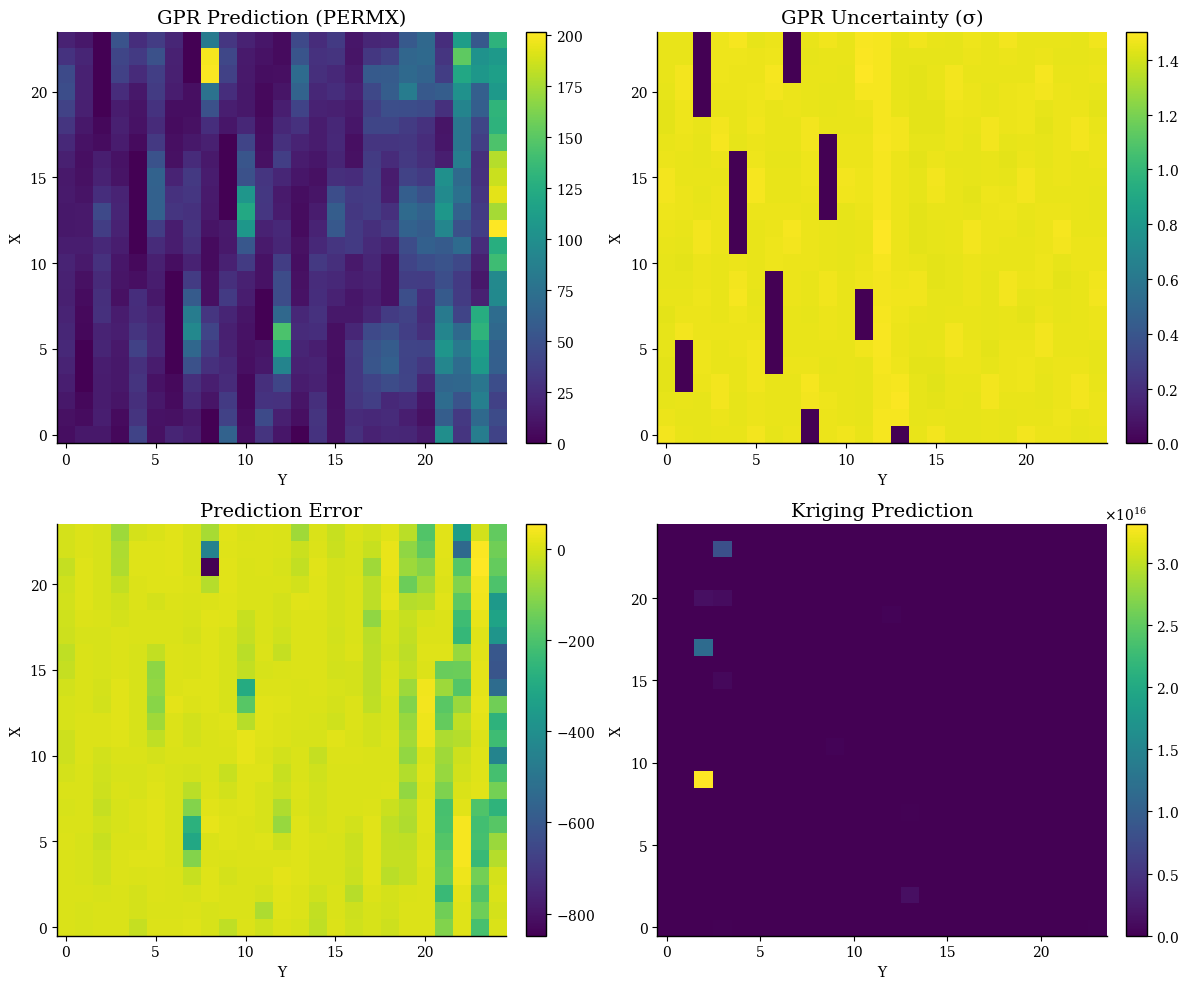

In [9]:
# Load slicespred = pd.read_csv("predicted_slice.csv", header = None).valuessigma = pd.read_csv("sigma_slice.csv", header = None).valueserror = pd.read_csv("error_slice.csv", header = None).valueskrig = pd.read_csv("kriging_pred_slice.csv", header = None).values# Set plot stylercParams["font.family"] = "serif"rcParams["axes.spines.top"] = FalsercParams["axes.spines.right"] = FalsercParams["axes.linewidth"] = 1.0fig, axs = plt.subplots(2, 2, figsize=(12, 10))titles = ["GPR Prediction (PERMX)","GPR Uncertainty (σ)","Prediction Error","Kriging Prediction",]data = [pred, sigma, error, krig]cmap = "viridis"for ax, title, d in zip(axs.ravel(), titles, data):im = ax.imshow(d, origin="lower", cmap = cmap, aspect="auto")ax.set_title(title, fontsize = 14)ax.set_xlabel("Y")ax.set_ylabel("X")cbar = fig.colorbar(im, ax = ax, fraction = 0.046, pad = 0.04)cbar.formatter = mticker.ScalarFormatter(useMathText = True)cbar.update_ticks()plt.tight_layout()plt.savefig("comparison_slices.png", dpi = 300)plt.show()